# Visualización 5: Análisis de la Progresión Melódica mediante Diagramas de Caja (Boxplots)

**Finalidad de este notebook:**
El objetivo de este documento es analizar cómo evoluciona la distribución de las notas MIDI a lo largo de una composición musical. En lugar de graficar cada nota de manera individual en una serie de tiempo (como en notebooks anteriores), dividiremos la pieza en **segmentos temporales discretos**. 

Utilizando **diagramas de caja (*boxplots*)**, visualizaremos estadísticamente el comportamiento de las notas (medianas, cuartiles y valores atípicos) en cada fragmento de la obra, permitiendo identificar cambios de registro, densidad y variabilidad melódica a medida que avanza la canción.

---
### 1. Importación de dependencias

Cargamos las librerías necesarias:
* **`mido`**: Para la lectura y parseo de los eventos del archivo `.midi`.
* **`pandas` y `numpy`**: Para la manipulación de los datos, agregación estadística y discretización del tiempo en segmentos temporales (*binning*).
* **`matplotlib.pyplot` y `seaborn`**: Para la representación gráfica avanzada de los *boxplots*.


In [1]:
import os
from glob import glob
import random
import mido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Definición del conjunto de datos

Definimos la ruta principal del dataset y utilizamos la librería `glob` para buscar recursivamente todos los archivos con extensión `.midi` en los subdirectorios. Esto nos generará una lista estructurada con todas las obras disponibles para analizar.


In [2]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

### 3. Lógica de Segmentación y Visualización Estadística

A continuación, definimos la función principal `visualizar_boxplots_progression`. Su lógica algorítmica consta de las siguientes fases:

1. **Parseo y Acumulación de Tiempo**: Se lee el archivo MIDI iterando sobre sus eventos. Filtramos los mensajes de tipo `note_on` con velocidad mayor a 0 y calculamos el `tiempo_acumulado` continuo.
2. **Creación del DataFrame**: Transformamos la lista de diccionarios en un `pd.DataFrame` para aprovechar el motor analítico de *Pandas*.
3. **Discretización (Binning)**: Utilizamos la función **`pd.cut()`** para agrupar dinámicamente todos los eventos musicales en un número definido de `num_segmentos` de igual duración. A cada nota se le asigna la etiqueta de su segmento temporal correspondiente.
4. **Transformación para Seaborn**: Extraemos los valores de *Pitch* por cada segmento en una lista de arreglos (`datos_boxplot`), la cual es requerida por `sns.boxplot`.
5. **Renderizado Gráfico**: Trazamos los diagramas de caja segmentados, lo que revelará visualmente la tendencia central y la dispersión de las frecuencias (notas) a medida que transcurre el tiempo en la obra.


In [ ]:
def visualizar_boxplots_progression(lista_archivos, num_segmentos=12, limite=3):
    for i, ruta in enumerate(lista_archivos[:limite]):
        mid = mido.MidiFile(ruta)
        notas = []
        tiempo_acumulado = 0
        
        for msg in mid:
            tiempo_acumulado += msg.time
            if msg.type == 'note_on' and msg.velocity > 0:
                notas.append({'tiempo': tiempo_acumulado, 'pitch': msg.note})
                
        df = pd.DataFrame(notas)
        

        df['segmento'] = pd.cut(df['tiempo'], bins=num_segmentos, labels=False)
        
        datos_boxplot = [df[df['segmento'] == g]['pitch'].values for g in range(num_segmentos)]
        
        plt.figure(figsize=(14, 6))
        sns.boxplot(data=datos_boxplot, palette='pastel', width=0.6)
        
        plt.title(f"Distribución de Notas por Segmento: {os.path.basename(ruta)}")
        plt.xlabel(f"Progreso de la obra ({num_segmentos} segmentos)")
        plt.ylabel("Pitch (Nota MIDI)")
        plt.grid(axis='y', linestyle='--', alpha=0.4)
        plt.show()

### 4. Ejecución del Análisis de Progresión

Finalmente, probamos la función con una pequeña muestra de archivos de nuestro dataset. 

> **Interpretación del Gráfico:** 
> * La **línea central** en cada caja representa la nota mediana tocada en ese momento.
> * El **tamaño de la caja (rango intercuartílico)** nos indica cuánta variabilidad de notas hubo (si se tocaron acordes muy amplios o si la melodía se mantuvo en un rango corto).
> * Los **puntos sueltos** corresponden a valores atípicos (*outliers*), lo que podría representar notas muy agudas o muy graves fuera del motivo principal de la pieza en ese segmento.


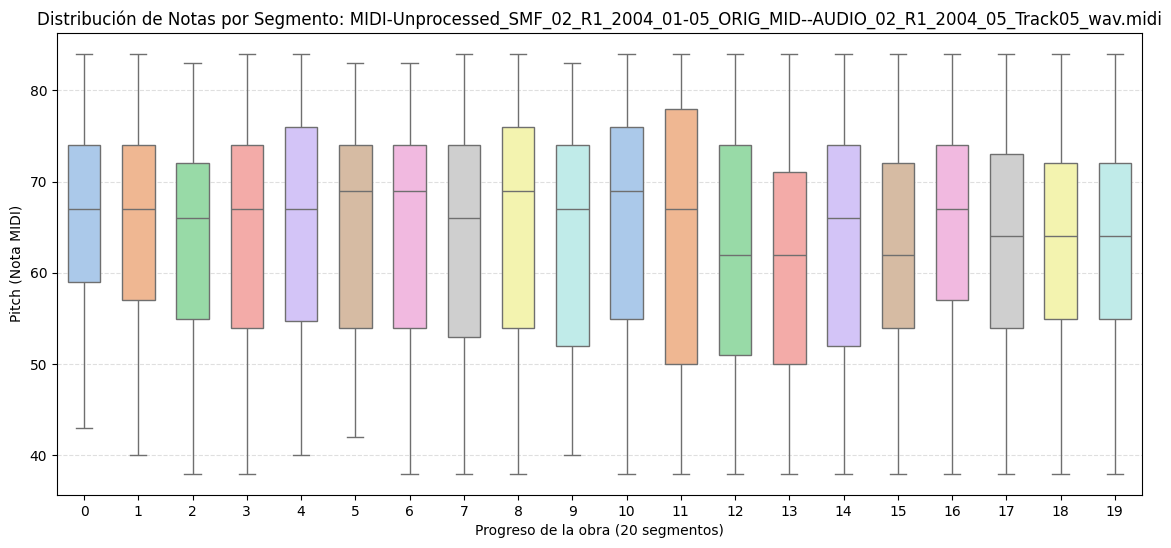

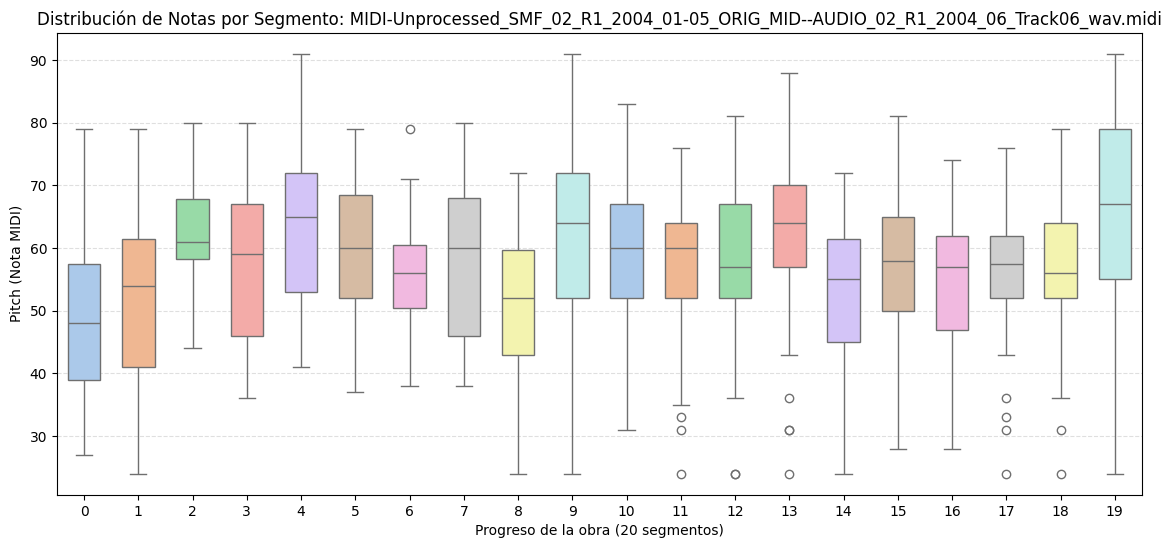

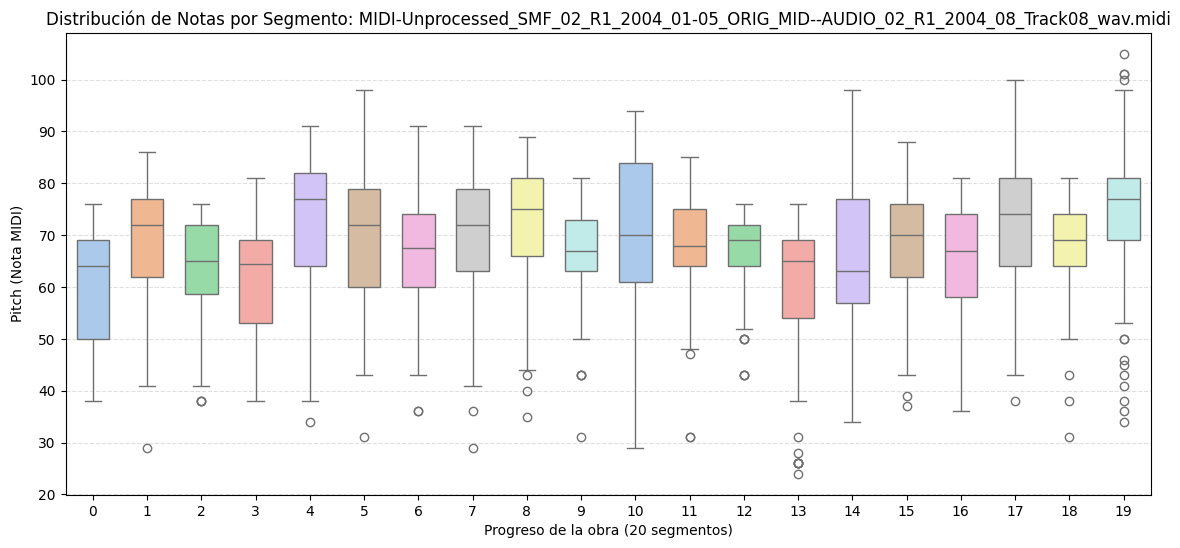

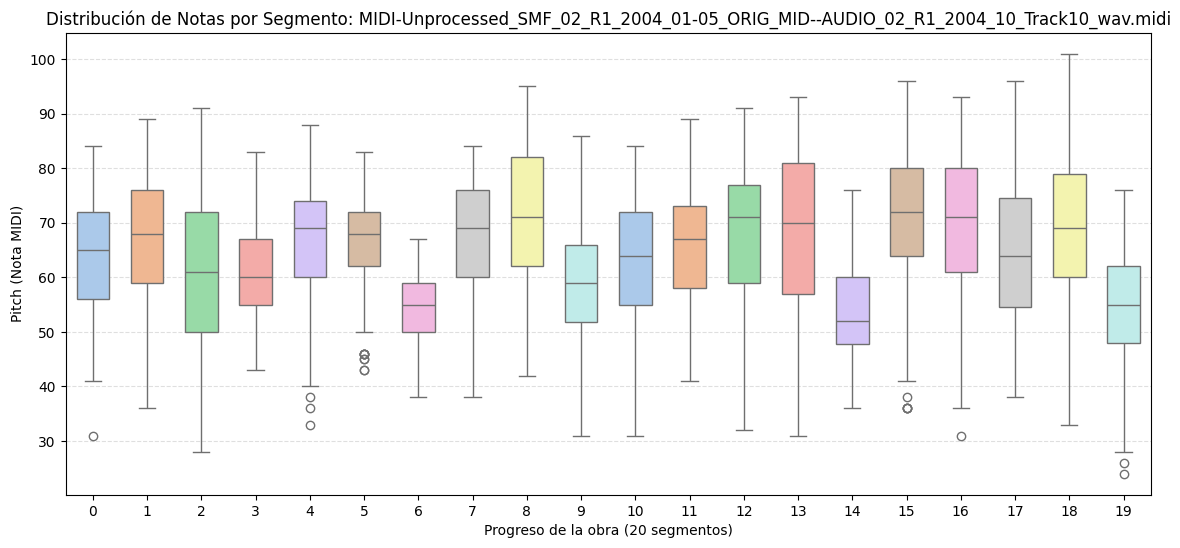

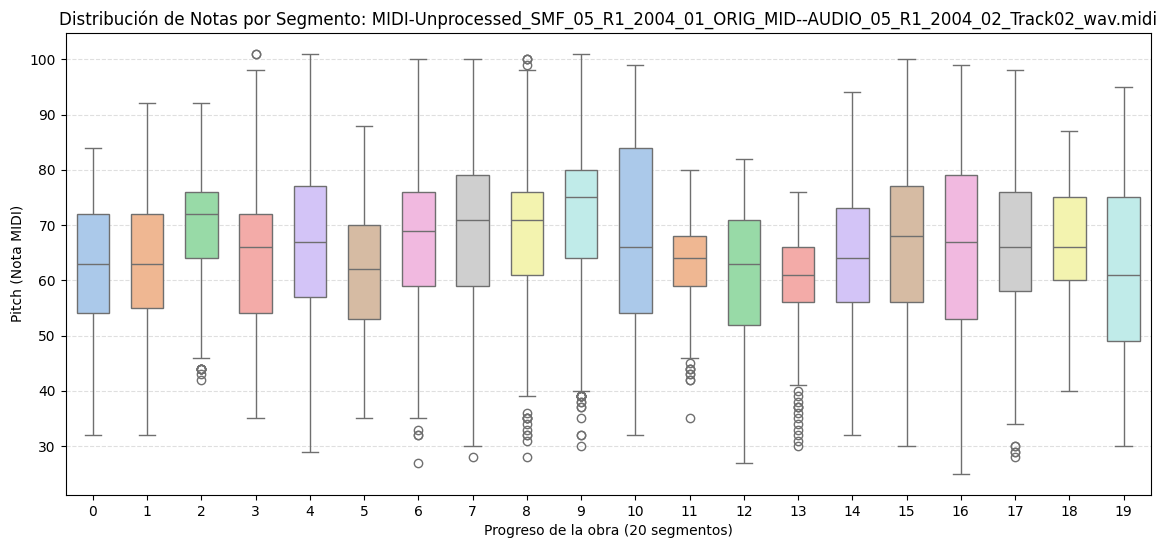

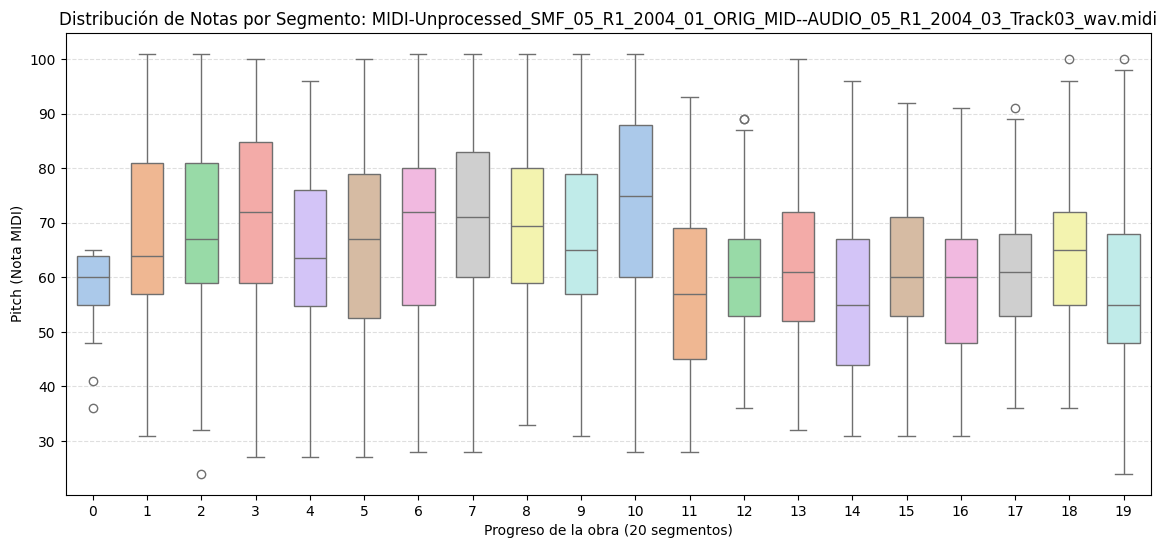

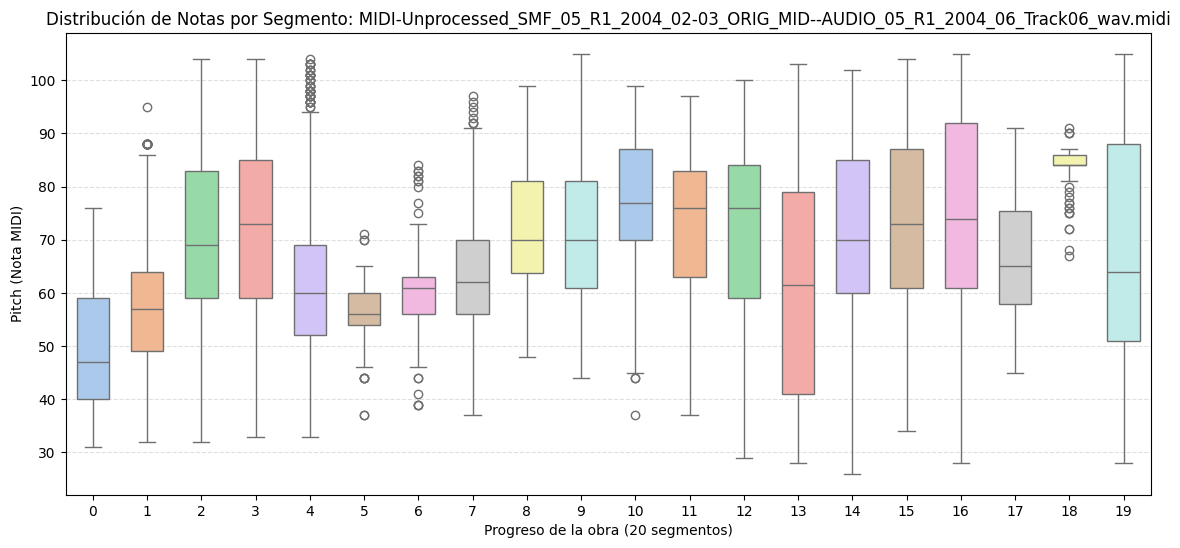

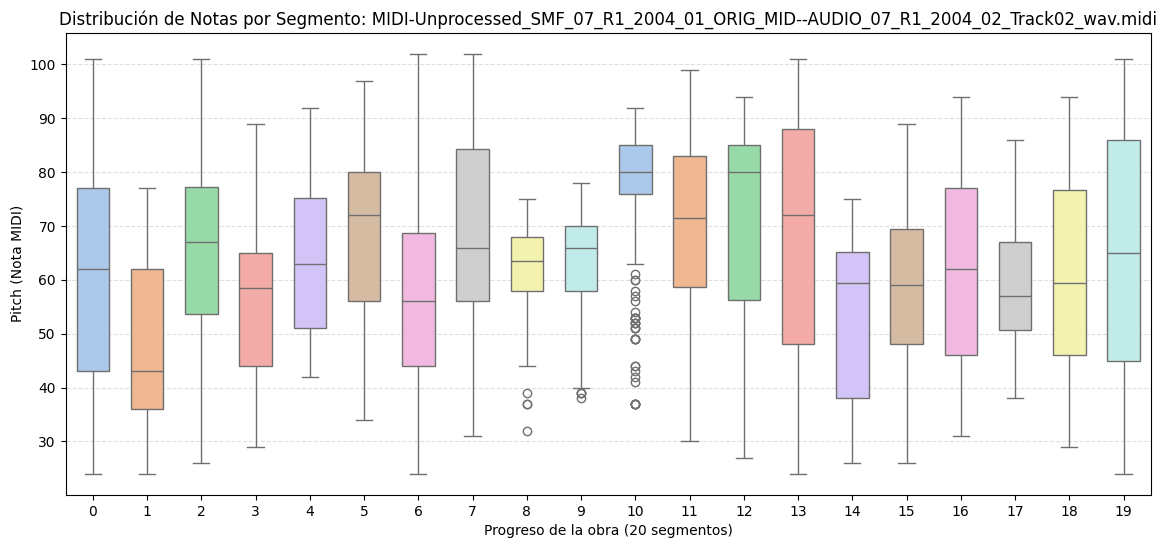

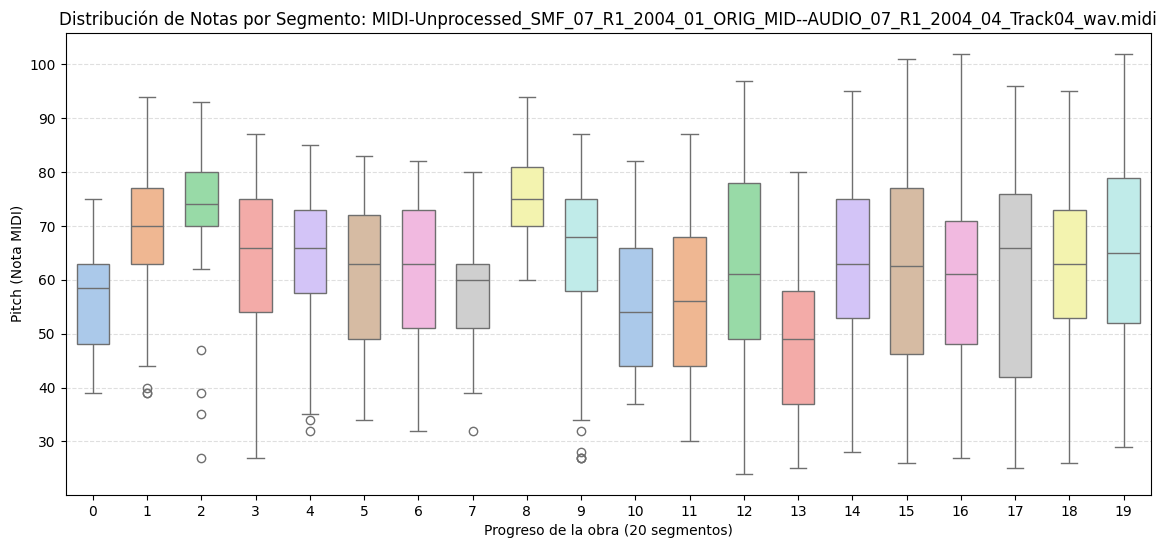

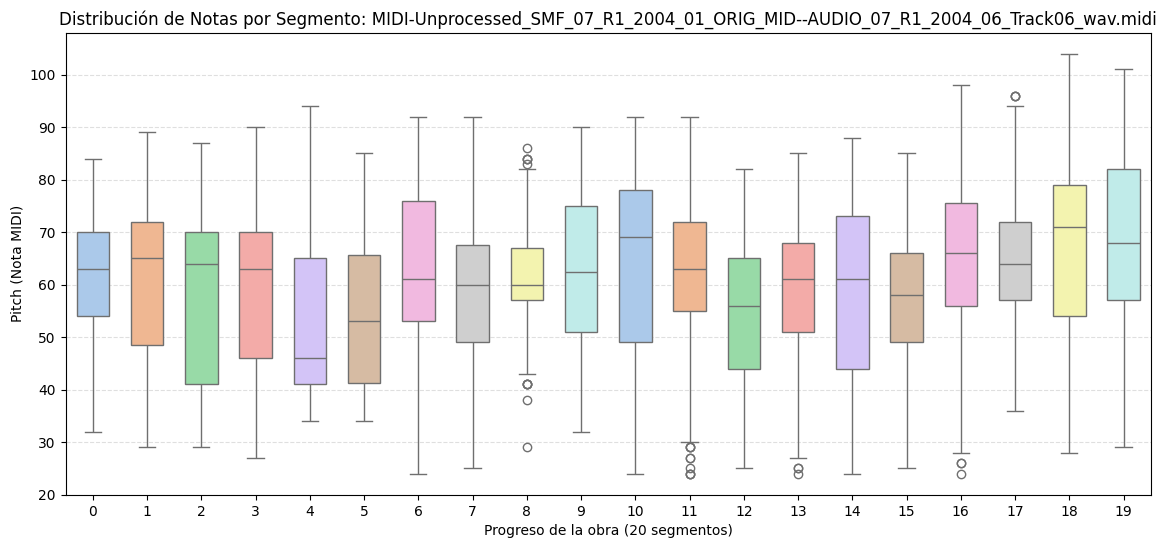

In [4]:
visualizar_boxplots_progression(archivos, num_segmentos=20, limite=10)